In [1]:
model_id = "lgbm_solusdt_l_fw60_2101_2605"


In [2]:
# Parameters
model_id = "lgbm_solusdt_s_fw60_2101_2605"


In [3]:
%matplotlib inline
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import Markdown, display

from analyst.lib.db_utils import find_repo_root as _find_root
sys.path.insert(0, str(_find_root() / "src"))
import utils

models_cfg   = utils.load_models_config()
meta         = models_cfg["models"][model_id]
artifact_dir = Path(utils._resolve_path(meta["artifact_dir"]))
search_dir   = artifact_dir / "search"

trials_path  = search_dir / "search_trials.jsonl"
best_path    = search_dir / "search_best.json"
prune_path   = search_dir / "pruning_report.json"

trials = [json.loads(l) for l in trials_path.read_text(encoding="utf-8").splitlines() if l.strip()]
best   = json.loads(best_path.read_text(encoding="utf-8"))

df = pd.DataFrame(trials)
df = df[df["objective_score"].notna()].reset_index(drop=True)

has_prune = prune_path.exists()
if has_prune:
    prune = json.loads(prune_path.read_text(encoding="utf-8"))

BLUE  = "#2E86AB"
RED   = "#E63946"
GREEN = "#52B788"
GRAY  = "#888888"

matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 9})


In [4]:
display(Markdown(f"**Model:** `{model_id}`  |  **Stage:** explore  |  **Trials:** {len(df)}  |  **Loss:** top10_lift (maximize)"))


**Model:** `lgbm_solusdt_s_fw60_2101_2605`  |  **Stage:** explore  |  **Trials:** 21  |  **Loss:** top10_lift (maximize)

In [5]:
best_ratio  = best.get("valid_top10_lift", float("nan"))
best_trial  = best.get("trial_no", "?")
best_gap    = best.get("train_valid_gap", float("nan"))
best_rho    = best.get("spearman_rho", float("nan"))
best_mono   = best.get("decile_monotonicity", float("nan"))
best_iter   = best.get("best_iteration", "?")

rows = [
    ("Best trial №",          best_trial),
    ("**valid_top10_lift**",  f"**{best_ratio:.4f}**"),
    ("train_top10_lift",      f"{best.get('train_top10_lift', float('nan')):.4f}"),
    ("Train–valid gap",       f"{best_gap:.4f}"),
    ("Spearman ρ (valid)",    f"{best_rho:.4f}"),
    ("Decile monotonicity",   f"{best_mono:.3f}"),
    ("Best iteration",        best_iter),
]
if has_prune:
    rows += [
        ("Features (selected)",   prune["n_selected"]),
        ("Zero-split removed",    prune["n_zero_split"]),
        ("Features (pruned)",     prune["n_pruned_selected"]),
    ]

display(Markdown("## Összefoglalás"))
tbl = pd.DataFrame(rows, columns=["Metric", "Value"])
display(Markdown(tbl.to_markdown(index=False)))


## Összefoglalás

| Metric               | Value      |
|:---------------------|:-----------|
| Best trial №         | 11         |
| **valid_top10_lift** | **0.0026** |
| train_top10_lift     | 0.0048     |
| Train–valid gap      | 0.0022     |
| Spearman ρ (valid)   | 0.3052     |
| Decile monotonicity  | 1.000      |
| Best iteration       | 820        |

## Trial Progressz

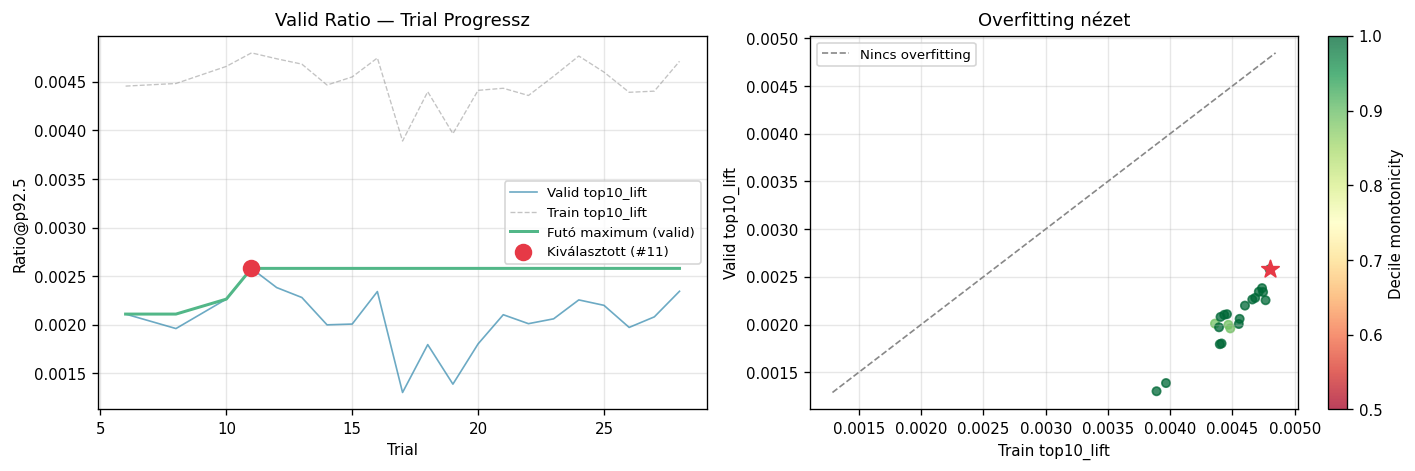

In [6]:
display(Markdown("## Trial Progressz"))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(df["trial_no"], df["valid_top10_lift"], color=BLUE, lw=1.0, alpha=0.7, label="Valid top10_lift")
ax.plot(df["trial_no"], df["train_top10_lift"], color=GRAY, lw=0.8, alpha=0.5, ls="--", label="Train top10_lift")
running_best = df["valid_top10_lift"].cummax()
ax.plot(df["trial_no"], running_best, color=GREEN, lw=1.8, label="Futó maximum (valid)")
brow = df[df["trial_no"] == best_trial]
if len(brow):
    ax.scatter(brow["trial_no"], brow["valid_top10_lift"], color=RED, s=90, zorder=5, label=f"Kiválasztott (#{best_trial})")
ax.set_xlabel("Trial")
ax.set_ylabel("Ratio@p92.5")
ax.set_title("Valid Ratio — Trial Progressz")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
sc = ax.scatter(df["train_top10_lift"], df["valid_top10_lift"],
                c=df["decile_monotonicity"].clip(0.5, 1.0),
                cmap="RdYlGn", vmin=0.5, vmax=1.0, s=25, alpha=0.75)
plt.colorbar(sc, ax=ax, label="Decile monotonicity")
lo = min(df["train_top10_lift"].min(), df["valid_top10_lift"].min()) * 0.99
hi = max(df["train_top10_lift"].max(), df["valid_top10_lift"].max()) * 1.01
ax.plot([lo, hi], [lo, hi], "--", color=GRAY, lw=1, label="Nincs overfitting")
if len(brow):
    ax.scatter(brow["train_top10_lift"], brow["valid_top10_lift"], color=RED, s=120, zorder=5, marker="*")
ax.set_xlabel("Train top10_lift")
ax.set_ylabel("Valid top10_lift")
ax.set_title("Overfitting nézet")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
display(Markdown("## Top 10 Trial"))
cols = ["trial_no", "valid_top10_lift", "train_top10_lift", "train_valid_gap",
        "spearman_rho", "decile_monotonicity", "valid_rmse", "best_iteration", "elapsed_s"]
avail = [c for c in cols if c in df.columns]
top10 = df.nlargest(10, "valid_top10_lift")[avail].copy()
top10.index = range(1, len(top10)+1)
display(Markdown(top10.round(4).to_markdown()))


## Top 10 Trial

|    |   trial_no |   valid_top10_lift |   train_top10_lift |   train_valid_gap |   spearman_rho |   decile_monotonicity |   valid_rmse |   best_iteration |   elapsed_s |
|---:|-----------:|-------------------:|-------------------:|------------------:|---------------:|----------------------:|-------------:|-----------------:|------------:|
|  1 |         11 |             0.0026 |             0.0048 |            0.0022 |         0.3052 |                     1 |       0.0067 |              820 |         5   |
|  2 |         12 |             0.0024 |             0.0047 |            0.0024 |         0.3019 |                     1 |       0.0067 |             2147 |        14.1 |
|  3 |         28 |             0.0023 |             0.0047 |            0.0024 |         0.3009 |                     1 |       0.0067 |              645 |         4.7 |
|  4 |         16 |             0.0023 |             0.0047 |            0.0024 |         0.3012 |                     1 |       0.0067 |              586 |         2.2 |
|  5 |         13 |             0.0023 |             0.0047 |            0.0024 |         0.2969 |                     1 |       0.0067 |             1892 |        11.5 |
|  6 |         10 |             0.0023 |             0.0047 |            0.0024 |         0.2966 |                     1 |       0.0067 |              664 |         2.7 |
|  7 |         24 |             0.0023 |             0.0048 |            0.0025 |         0.2963 |                     1 |       0.0067 |             2090 |        10.2 |
|  8 |         25 |             0.0022 |             0.0046 |            0.0024 |         0.2925 |                     1 |       0.0067 |             1319 |         6.6 |
|  9 |          6 |             0.0021 |             0.0045 |            0.0023 |         0.2695 |                     1 |       0.0068 |             1447 |         4.8 |
| 10 |         21 |             0.0021 |             0.0044 |            0.0023 |         0.2752 |                     1 |       0.0068 |              951 |         4   |

In [8]:
display(Markdown("## Best Hyperparaméterek"))
params = best.get("params", {})
rows_p = [{"Paraméter": k, "Érték": v} for k, v in sorted(params.items())]
display(Markdown(pd.DataFrame(rows_p).to_markdown(index=False)))


## Best Hyperparaméterek

| Paraméter         |         Érték |
|:------------------|--------------:|
| colsample_bytree  |   0.354171    |
| extra_trees       |   1           |
| learning_rate     |   0.0162075   |
| max_bin           |  63           |
| max_depth         |   5           |
| min_child_samples | 299           |
| min_child_weight  |   0.000482842 |
| min_split_gain    |   0           |
| num_leaves        |  32           |
| path_smooth       |   0.00301621  |
| reg_alpha         |   0.0511012   |
| reg_lambda        |  43.2543      |
| subsample         |   0.880365    |

## Paraméter Hatás (valid_top10_lift)

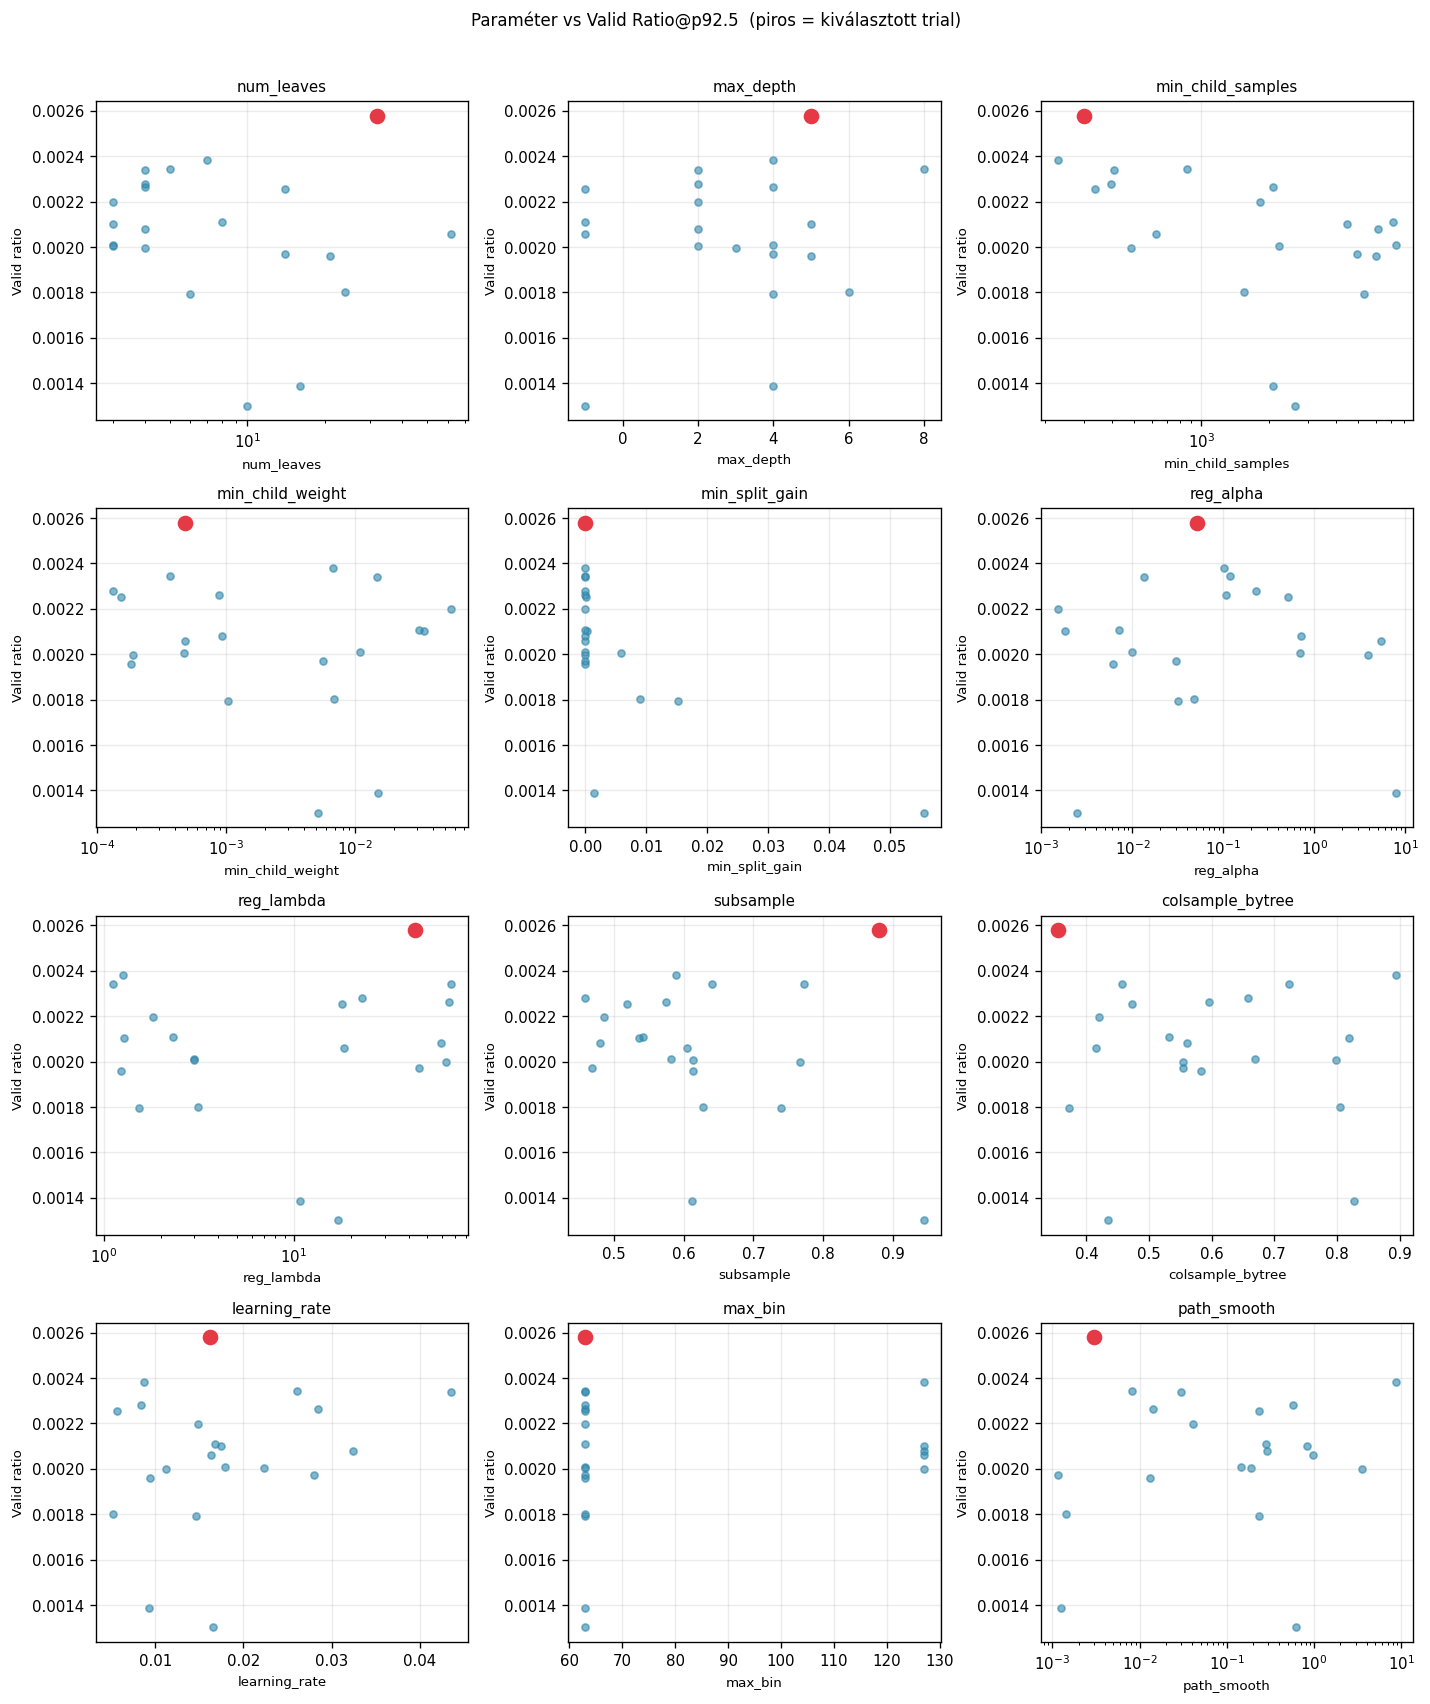

In [9]:
display(Markdown("## Paraméter Hatás (valid_top10_lift)"))
first_params = df["params"].dropna().iloc[0] if len(df) > 0 else {}
float_params = [k for k, v in (first_params or {}).items() if isinstance(v, (int, float)) and not isinstance(v, bool)]
n_fp = len(float_params)
if n_fp > 0:
    ncols = 3
    nrows = (n_fp + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.5 * nrows), squeeze=False)
    for i, p in enumerate(float_params):
        ax = axes[i // ncols][i % ncols]
        vals = df["params"].apply(lambda d: d.get(p) if isinstance(d, dict) else None).astype(float)
        ax.scatter(vals, df["valid_top10_lift"], s=18, alpha=0.6, color=BLUE)
        ax.scatter([params.get(p)], [best_ratio], color=RED, s=70, zorder=5)
        ax.set_xlabel(p, fontsize=8)
        ax.set_ylabel("Valid ratio", fontsize=8)
        ax.set_title(p, fontsize=9)
        ax.grid(alpha=0.25)
        if vals.dropna().min() > 0 and vals.dropna().max() / vals.dropna().min() > 10:
            ax.set_xscale("log")
    for j in range(i + 1, nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    plt.suptitle("Paraméter vs Valid Ratio@p92.5  (piros = kiválasztott trial)", y=1.01, fontsize=10)
    plt.tight_layout()
    plt.show()


In [10]:
display(Markdown("## Feature Importance (Post-Prune)"))
if has_prune:
    fi_df = pd.DataFrame(prune["all_feature_importance"])
    used  = fi_df[fi_df["split"] > 0].head(30).copy()
    used["gain_norm"] = used["gain"] / used["gain"].max()

    fig, ax = plt.subplots(figsize=(9, max(5, len(used) * 0.30)))
    bars = ax.barh(used["feature"][::-1], used["gain"][::-1], color=GREEN, alpha=0.8)
    ax.set_xlabel("Gain importance")
    ax.set_title(f"Top-{len(used)} Feature (split > 0)  —  összesen {prune['n_pruned_selected']} feature használt")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    if prune["zero_split_features"]:
        display(Markdown(
            f"**Zero-split (eltávolítva, {prune['n_zero_split']} db):** "
            + ", ".join(f"`{f}`" for f in sorted(prune["zero_split_features"]))
        ))
    else:
        display(Markdown(
            f"**Nincs zero-split feature** — mind a {prune['n_selected']} selected feature "
            "részt vett legalább egy vágásban a best params modellben."
        ))
else:
    display(Markdown("_Pruning report hiányzik. Futtasd `run_prune()` a search után._"))


## Feature Importance (Post-Prune)

_Pruning report hiányzik. Futtasd `run_prune()` a search után._

In [11]:
display(Markdown("## Learning Curve (Best Trial)"))
curve_path = search_dir / "trial_curves" / f"trial_{int(best_trial):04d}.json"
if curve_path.exists():
    curve = json.loads(curve_path.read_text(encoding="utf-8"))
    train_loss = curve.get("train", {}).get("quantile", [])
    valid_loss = curve.get("valid", {}).get("quantile", [])
    if train_loss and valid_loss:
        iters = list(range(1, len(train_loss) + 1))
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.plot(iters, train_loss, color=BLUE, lw=1.2, label="Train quantile loss")
        ax.plot(iters, valid_loss, color=RED,  lw=1.2, label="Valid quantile loss")
        best_it = best.get("best_iteration")
        if best_it:
            ax.axvline(best_it, color=GREEN, lw=1.2, ls="--", label=f"Best iter={best_it}")
        ax.set_xlabel("Iteráció")
        ax.set_ylabel("Quantile loss (α=0.925)")
        ax.set_title(f"Learning Curve — Best Trial #{best_trial}")
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    display(Markdown(f"_Learning curve nem található: {curve_path}_"))


## Learning Curve (Best Trial)